# Hacia el agua limpia para todos: Parte 1 y Parte 2

**Objetivo de este notebook.** Preparar el dataset Water Potability y entrenar una línea base SVM-RBF clásica bajo un protocolo estricto:

- imputación por mediana por clase;
- estandarización sin fuga de información;
- balanceo de clases por submuestreo en training;
- división estratificada 80/20;
- validación cruzada estratificada de 5 particiones;
- grilla `C in {0.1, 1, 10}` y `gamma in {scale, auto, 0.01}`;
- reporte de exactitud, precisión, recall, F1, especificidad, balanced accuracy, MCC y matriz de confusión.

La grilla audita distintos espacios de variables, pero la base fisicoquímica predefinida para continuar es `chem5_v01`: `Sulfate`, `ph`, `Conductivity`, `Chloramines` y `Hardness`.

Además se congela un subconjunto balanceado de 80 muestras para la fase cuántica posterior. En cada uno de los 5 folds se usan 64 muestras para entrenamiento y 16 para validación; las 80 muestras participan en la evaluación OOF.


## Aprendizajes heredados y decisión de dominio

El README y los artefactos previos sugieren tres reglas para este reinicio:

1. **No seleccionar solo por F1.** Un threshold negativo puede subir F1 al predecir más muestras como potables, pero también aumenta falsos positivos: aguas no potables marcadas como potables.
2. **No comparar poblaciones distintas.** Una QSVM de 80 filas debe compararse contra una SVM entrenada y evaluada sobre esas mismas 80 filas y folds.
3. **Separar ranking estadístico de decisión de dominio.** `chem5_prev` obtiene una ventaja pequeña en CV, pero se fija `chem5_v01` como base de trabajo porque reemplaza `Solids` por `Conductivity`. Para este experimento, conductividad aporta una variable fisicoquímica directamente interpretable como respuesta al contenido iónico disuelto, mientras que `Solids` es una medida agregada menos específica. La diferencia de métricas es pequeña y se prioriza coherencia de dominio y trazabilidad para los circuitos de cinco qubits.

Esta preferencia no convierte a `chem5_v01` en un estándar regulatorio ni prueba causalidad; es una decisión experimental predefinida.


0. Verificacion del entorno en Colab
Si aparece AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe', el problema es una mezcla incompatible entre numpy, scipy y scikit-learn en la sesion, no el codigo del kernel. Ejecuta desde arriba: esta celda detecta ese estado, reinstala un stack compatible en Colab y detiene la ejecucion para que reinicies el runtime antes de continuar.

In [1]:
# 1. Dependencias reproducibles para Google Colab
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "scikit-learn==1.6.1",
        "imbalanced-learn==0.14.2",
        "pytket==2.18.1",
        "joblib>=1.4,<2",
        "scipy==1.15.3",
        "pandas==2.2.3",
        "matplotlib==3.10.0",
    ])

In [2]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

from pathlib import Path
import itertools
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

TARGET = "Potability"
CLASS_LABELS = [0, 1]
CLASS_NAMES = {0: "No potable", 1: "Potable"}

SEEDS = {
    "split": 20260801,
    "feature_cv": 20260803,
    "quantum_sample": 20260805,
    "outer_folds": 20260806,
    "undersample_base": 20260820,
}

C_GRID = [0.1, 1.0, 10.0]
GAMMA_GRID = ["scale", "auto", 0.01]
N_SPLITS = 5
QUANTUM_ROWS = 80

FEATURE_SETS = {
    "raw9": [
        "ph", "Hardness", "Solids", "Chloramines", "Sulfate",
        "Conductivity", "Organic_carbon", "Trihalomethanes", "Turbidity",
    ],
    "chem5_v01": ["Sulfate", "ph", "Conductivity", "Chloramines", "Hardness"],
    "chem5_prev": ["Sulfate", "ph", "Solids", "Chloramines", "Hardness"],
    "chem4_v01": ["Sulfate", "ph", "Conductivity", "Chloramines"],
    "chem4_prev": ["Sulfate", "ph", "Solids", "Chloramines"],
}

PREFERRED_FEATURE_SET = "chem5_v01"
LOCKED_FEATURES = ["Sulfate", "ph", "Conductivity", "Chloramines", "Hardness"]
if FEATURE_SETS[PREFERRED_FEATURE_SET] != LOCKED_FEATURES:
    raise RuntimeError(
        f"Contrato de features inconsistente: {FEATURE_SETS[PREFERRED_FEATURE_SET]} != {LOCKED_FEATURES}"
    )

PREFERRED_FEATURE_REASON = (
    "Se prioriza una base fisicoquimica interpretable: Sulfate, ph, Conductivity, "
    "Chloramines y Hardness. Conductivity reemplaza a Solids como proxy directo "
    "de la carga ionica disuelta; la pequena diferencia de CV se acepta como trade-off de dominio."
)


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "water_potability.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontro data/water_potability.csv en la ruta actual ni en sus padres.")


if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")
else:
    PROJECT_ROOT = Path(os.environ["WATER_PROJECT_ROOT"]).resolve() if os.environ.get("WATER_PROJECT_ROOT") else find_project_root()

DATA_PATH = PROJECT_ROOT / "water_potability.csv"
PREVIOUS_DIR = PROJECT_ROOT / "previous_experiment"
ARTIFACT_DIR = Path(os.environ.get("WATER_ARTIFACT_DIR", PROJECT_ROOT / "artifacts_v1_2"))
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATA_PATH}")
print(f"Artifacts: {ARTIFACT_DIR}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks
Dataset: /content/drive/MyDrive/Colab Notebooks/water_potability.csv
Artifacts: /content/drive/MyDrive/Colab Notebooks/artifacts_v1


## 1. Carga y contrato del dataset

El dataset original se carga con `source_index` para poder congelar filas y verificar que el subconjunto de 80 no intersecte el holdout.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.reset_index(names="source_index")

required_columns = set(FEATURE_SETS["raw9"] + [TARGET])
missing_columns = sorted(required_columns - set(df_raw.columns))
if missing_columns:
    raise ValueError(f"Columnas faltantes en el dataset: {missing_columns}")

if not set(df_raw[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError("La variable objetivo debe ser binaria con clases 0 y 1.")

contract = {
    "dataset_sha256": sha256_file(DATA_PATH),
    "shape": df_raw.shape,
    "class_counts": df_raw[TARGET].value_counts().sort_index().to_dict(),
    "missing_counts": df_raw.isna().sum().to_dict(),
}

missing_report = (
    df_raw.isna().sum()
    .rename("missing")
    .to_frame()
    .assign(missing_pct=lambda d: d["missing"] / len(df_raw))
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)

class_report = (
    df_raw[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("Potability")
    .reset_index(name="rows")
)
class_report["share"] = class_report["rows"] / len(df_raw)
class_report["label"] = class_report["Potability"].map(CLASS_NAMES)

print(json.dumps(contract, indent=2))
display(class_report)
display(missing_report)

with (ARTIFACT_DIR / "data_contract.json").open("w", encoding="utf-8") as f:
    json.dump(contract, f, indent=2)

{
  "dataset_sha256": "904004bde729bfe3d2e195f46343bceead09e32a0eb95bb8184e7e20e029b2bf",
  "shape": [
    3276,
    10
  ],
  "class_counts": {
    "0": 1998,
    "1": 1278
  },
  "missing_counts": {
    "ph": 491,
    "Hardness": 0,
    "Solids": 0,
    "Chloramines": 0,
    "Sulfate": 781,
    "Conductivity": 0,
    "Organic_carbon": 0,
    "Trihalomethanes": 162,
    "Turbidity": 0,
    "Potability": 0
  }
}


,Potability,rows,share,label
0,0,1998,0.60989,No potable
1,1,1278,0.39011,Potable


,missing,missing_pct
Sulfate,781,0.238400
ph,491,0.149878
Trihalomethanes,162,0.049451


## 2. Split 80/20 y reglas de preprocesamiento

Reglas aplicadas en todo el notebook:

- se divide antes de imputar, escalar o balancear;
- las medianas por clase se calculan solo con el training de cada fold o con el training completo final;
- el escalador se ajusta solo en training;
- el submuestreo se aplica solo al training, no al holdout;
- el holdout queda reservado para evaluacion final, no para seleccionar hiperparametros.

Nota metodologica: la imputacion por mediana por clase usa la etiqueta para escoger la mediana de entrenamiento correspondiente. Esto replica el enunciado del reto, pero no es directamente desplegable porque en produccion la etiqueta es desconocida.

In [4]:
X_all = df.drop(columns=[TARGET])
y_all = df[TARGET].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    stratify=y_all,
    random_state=SEEDS["split"],
)

split_report = pd.DataFrame([
    {"split": "train", "rows": len(y_train), "class_0": int((y_train == 0).sum()), "class_1": int((y_train == 1).sum())},
    {"split": "holdout", "rows": len(y_test), "class_0": int((y_test == 0).sum()), "class_1": int((y_test == 1).sum())},
])
split_report["class_1_share"] = split_report["class_1"] / split_report["rows"]

display(split_report)
split_report.to_csv(ARTIFACT_DIR / "train_holdout_split_report.csv", index=False)

,split,rows,class_0,class_1,class_1_share
0,train,2620,1598,1022,0.390076
1,holdout,656,400,256,0.390244


In [5]:
def fit_class_medians(X: pd.DataFrame, y: pd.Series) -> dict:
    y = pd.Series(np.asarray(y, dtype=int), index=X.index)
    by_class = {
        int(cls): X.loc[y == cls].median(numeric_only=True)
        for cls in sorted(pd.unique(y))
    }
    return {"by_class": by_class, "global": X.median(numeric_only=True)}


def transform_class_medians(X: pd.DataFrame, y: pd.Series, stats: dict) -> pd.DataFrame:
    X_imp = X.copy()
    y = pd.Series(np.asarray(y, dtype=int), index=X.index)
    for cls, medians in stats["by_class"].items():
        idx = y == cls
        X_imp.loc[idx] = X_imp.loc[idx].fillna(medians)
    return X_imp.fillna(stats["global"])


def undersample_arrays(X_array: np.ndarray, y: pd.Series | np.ndarray, seed: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_array = np.asarray(y, dtype=int)
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y_array, return_counts=True)
    n_min = int(counts.min())
    keep = []
    for cls in classes:
        cls_idx = np.flatnonzero(y_array == cls)
        keep.extend(rng.choice(cls_idx, size=n_min, replace=False).tolist())
    keep = np.array(sorted(keep), dtype=int)
    return X_array[keep], y_array[keep], keep


def classification_metrics(y_true, y_pred) -> dict:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    tn, fp, fn, tp = [int(v) for v in cm.ravel()]
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def make_splits(y: pd.Series, n_splits: int, seed: int, fold_assignments=None):
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    if fold_assignments is None:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return list(skf.split(np.zeros(len(y_reset)), y_reset))
    folds = pd.Series(fold_assignments).reset_index(drop=True).to_numpy()
    return [(np.flatnonzero(folds != fold), np.flatnonzero(folds == fold)) for fold in sorted(np.unique(folds))]


def fit_fold_model(X_tr_raw, y_tr, X_va_raw, y_va, features, C, gamma, balance_training: bool, seed: int):
    medians = fit_class_medians(X_tr_raw[features], y_tr)
    X_tr_imp = transform_class_medians(X_tr_raw[features], y_tr, medians)
    X_va_imp = transform_class_medians(X_va_raw[features], y_va, medians)

    scaler = StandardScaler().fit(X_tr_imp)
    X_tr_scaled = scaler.transform(X_tr_imp)
    X_va_scaled = scaler.transform(X_va_imp)

    if balance_training:
        X_fit, y_fit, _ = undersample_arrays(X_tr_scaled, y_tr, seed=seed)
    else:
        X_fit, y_fit = X_tr_scaled, np.asarray(y_tr, dtype=int)

    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    clf.fit(X_fit, y_fit)
    pred = clf.predict(X_va_scaled)
    score = clf.decision_function(X_va_scaled)
    return clf, pred, score


def cross_validated_oof(
    X_raw: pd.DataFrame,
    y: pd.Series,
    features: list[str],
    C: float,
    gamma,
    n_splits: int = N_SPLITS,
    seed: int = SEEDS["feature_cv"],
    balance_training: bool = True,
    fold_assignments=None,
):
    X_reset = X_raw.reset_index(drop=True)
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    source_index = X_reset["source_index"] if "source_index" in X_reset.columns else pd.Series(range(len(X_reset)))

    oof_pred = np.empty(len(y_reset), dtype=int)
    oof_score = np.empty(len(y_reset), dtype=float)
    fold_rows = []

    for fold_number, (tr_idx, va_idx) in enumerate(make_splits(y_reset, n_splits, seed, fold_assignments)):
        _, pred, score = fit_fold_model(
            X_reset.iloc[tr_idx],
            y_reset.iloc[tr_idx],
            X_reset.iloc[va_idx],
            y_reset.iloc[va_idx],
            features,
            C,
            gamma,
            balance_training=balance_training,
            seed=SEEDS["undersample_base"] + fold_number,
        )
        oof_pred[va_idx] = pred
        oof_score[va_idx] = score
        row = {"fold": fold_number, "C": C, "gamma": gamma, "n_train": len(tr_idx), "n_valid": len(va_idx)}
        row.update(classification_metrics(y_reset.iloc[va_idx], pred))
        fold_rows.append(row)

    oof_df = pd.DataFrame({
        "source_index": source_index,
        "y_true": y_reset,
        "decision_score": oof_score,
        "y_pred": oof_pred,
    })
    return pd.DataFrame(fold_rows), oof_df


def cross_validate_grid(
    X_raw: pd.DataFrame,
    y: pd.Series,
    features: list[str],
    C_grid: list[float] = C_GRID,
    gamma_grid: list = GAMMA_GRID,
    n_splits: int = N_SPLITS,
    seed: int = SEEDS["feature_cv"],
    balance_training: bool = True,
    fold_assignments=None,
):
    summary_rows = []
    all_fold_rows = []
    for C, gamma in itertools.product(C_grid, gamma_grid):
        fold_df, _ = cross_validated_oof(
            X_raw,
            y,
            features,
            C,
            gamma,
            n_splits=n_splits,
            seed=seed,
            balance_training=balance_training,
            fold_assignments=fold_assignments,
        )
        summary = {"C": C, "gamma": gamma}
        for metric in ["accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc"]:
            summary[f"{metric}_mean"] = float(fold_df[metric].mean())
            summary[f"{metric}_std"] = float(fold_df[metric].std(ddof=1))
        summary_rows.append(summary)
        all_fold_rows.append(fold_df)
    return pd.DataFrame(summary_rows), pd.concat(all_fold_rows, ignore_index=True)


def fit_final_svm(X_train, y_train, X_eval, y_eval, features, C, gamma, balance_training=True):
    medians = fit_class_medians(X_train[features], y_train)
    X_train_imp = transform_class_medians(X_train[features], y_train, medians)
    X_eval_imp = transform_class_medians(X_eval[features], y_eval, medians)

    scaler = StandardScaler().fit(X_train_imp)
    X_train_scaled = scaler.transform(X_train_imp)
    X_eval_scaled = scaler.transform(X_eval_imp)

    if balance_training:
        X_fit, y_fit, keep = undersample_arrays(X_train_scaled, y_train, seed=SEEDS["undersample_base"])
    else:
        X_fit, y_fit, keep = X_train_scaled, np.asarray(y_train, dtype=int), np.arange(len(y_train))

    clf = SVC(kernel="rbf", C=C, gamma=gamma)
    clf.fit(X_fit, y_fit)

    eval_pred = clf.predict(X_eval_scaled)
    eval_score = clf.decision_function(X_eval_scaled)
    train_score = clf.decision_function(X_train_scaled)

    metrics = classification_metrics(y_eval, eval_pred)
    metrics.update({
        "C": C,
        "gamma": gamma,
        "train_rows_before_balance": int(len(y_train)),
        "train_rows_after_balance": int(len(y_fit)),
        "eval_rows": int(len(y_eval)),
    })
    bundle = {
        "model": clf,
        "scaler": scaler,
        "medians": medians,
        "train_scores": train_score,
        "eval_scores": eval_score,
        "eval_pred": eval_pred,
        "balance_keep_positions": keep,
    }
    return metrics, bundle


def choose_threshold_max_f1(y_true, decision_scores) -> tuple[float, dict]:
    y_true = np.asarray(y_true, dtype=int)
    decision_scores = np.asarray(decision_scores, dtype=float)
    best_threshold = 0.0
    best_metrics = classification_metrics(y_true, decision_scores >= 0.0)
    for threshold in np.unique(decision_scores):
        candidate_metrics = classification_metrics(y_true, decision_scores >= threshold)
        if candidate_metrics["f1"] > best_metrics["f1"]:
            best_threshold = float(threshold)
            best_metrics = candidate_metrics
    return best_threshold, best_metrics


def assign_balanced_folds(y: pd.Series, n_splits: int, seed: int) -> np.ndarray:
    y_reset = pd.Series(np.asarray(y, dtype=int)).reset_index(drop=True)
    folds = np.empty(len(y_reset), dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (_, valid_idx) in enumerate(skf.split(np.zeros(len(y_reset)), y_reset)):
        folds[valid_idx] = fold
    return folds


def select_score_quantile_subset(y_pool: pd.Series, scores: np.ndarray, n_per_class: int) -> list[int]:
    y_array = np.asarray(y_pool, dtype=int)
    selected = []
    for cls in CLASS_LABELS:
        cls_positions = np.flatnonzero(y_array == cls)
        ordered = cls_positions[np.argsort(scores[cls_positions])]
        pick_positions = np.linspace(0, len(ordered) - 1, n_per_class).round().astype(int)
        chosen = list(dict.fromkeys(ordered[pick_positions].tolist()))
        if len(chosen) < n_per_class:
            for candidate in ordered:
                if candidate not in chosen:
                    chosen.append(int(candidate))
                if len(chosen) == n_per_class:
                    break
        selected.extend(chosen[:n_per_class])
    return sorted(selected)

## 3. Auditoría de features con SVM-RBF y CV estricta

La grilla se evalúa sobre todos los espacios de variables. El ranking estadístico se conserva completo para auditoría. Sin embargo, el modelo de trabajo queda **predefinido como `chem5_v01`** por la base fisicoquímica descrita arriba, siempre usando dentro de ese espacio la mejor combinación de `C` y `gamma` según F1 medio de CV, con `balanced_accuracy` y MCC como desempates.

> **Bloqueo de selección:** no se usa `feature_cv_summary.iloc[0]`, porque esa expresión toma el mejor candidato global y puede volver a elegir `chem5_prev`. Primero se filtra `feature_set == "chem5_v01"` y luego se escogen `C` y `gamma` dentro de ese único espacio.


In [6]:
feature_cv_summaries = []
feature_cv_folds = []

for feature_set_name, features in FEATURE_SETS.items():
    print(f"Evaluando {feature_set_name} ({len(features)} features): {features}")
    summary_df, fold_df = cross_validate_grid(
        X_train_raw,
        y_train,
        features,
        balance_training=True,
    )
    summary_df.insert(0, "feature_set", feature_set_name)
    summary_df.insert(1, "n_features", len(features))
    summary_df.insert(2, "features", "|".join(features))
    fold_df.insert(0, "feature_set", feature_set_name)
    feature_cv_summaries.append(summary_df)
    feature_cv_folds.append(fold_df)

feature_cv_summary = pd.concat(feature_cv_summaries, ignore_index=True)
feature_cv_fold_metrics = pd.concat(feature_cv_folds, ignore_index=True)
feature_cv_summary = feature_cv_summary.sort_values(
    ["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)

feature_cv_summary.to_csv(ARTIFACT_DIR / "feature_cv_summary.csv", index=False)
feature_cv_fold_metrics.to_csv(ARTIFACT_DIR / "feature_cv_fold_metrics.csv", index=False)

display(feature_cv_summary[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean",
    "specificity_mean", "balanced_accuracy_mean", "mcc_mean",
]].head(12))

Evaluando raw9 (9 features): ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']
Evaluando chem5_v01 (5 features): ['Sulfate', 'ph', 'Conductivity', 'Chloramines', 'Hardness']
Evaluando chem5_prev (5 features): ['Sulfate', 'ph', 'Solids', 'Chloramines', 'Hardness']
Evaluando chem4_v01 (4 features): ['Sulfate', 'ph', 'Conductivity', 'Chloramines']
Evaluando chem4_prev (4 features): ['Sulfate', 'ph', 'Solids', 'Chloramines']


,feature_set,n_features,C,gamma,accuracy_mean,precision_mean,recall_mean,f1_mean,specificity_mean,balanced_accuracy_mean,mcc_mean
0,chem5_prev,5,10.0,scale,0.641603,0.536154,0.601846,0.566642,0.667098,0.634472,0.264628
1,chem5_prev,5,10.0,auto,0.637786,0.531400,0.602817,0.564519,0.660212,0.631514,0.258456
2,chem5_v01,5,10.0,auto,0.635496,0.530183,0.588077,0.557302,0.665831,0.626954,0.250233
3,chem5_v01,5,10.0,scale,0.634351,0.528931,0.585146,0.555359,0.665827,0.625486,0.247384
4,raw9,9,10.0,scale,0.621756,0.512226,0.602846,0.553426,0.633932,0.618389,0.231906
5,raw9,9,10.0,auto,0.620992,0.511350,0.603826,0.553347,0.632053,0.617940,0.230959
6,chem5_prev,5,1.0,auto,0.645802,0.545069,0.561722,0.551538,0.699638,0.630680,0.260771
7,raw9,9,1.0,scale,0.634733,0.529052,0.572482,0.549582,0.674585,0.623533,0.244060
8,chem5_prev,5,1.0,scale,0.643511,0.542275,0.557814,0.548102,0.698389,0.628102,0.255737
9,chem5_v01,5,1.0,auto,0.639695,0.536223,0.560693,0.547568,0.690241,0.625467,0.249237


## 4. Evaluación en holdout reservado

Para cada espacio de features se toma su mejor configuración por CV y se evalúa una sola vez en el holdout 80/20. El holdout no decide hiperparámetros ni la preferencia de variables. La configuración operativa se fija en `chem5_v01`, aunque `chem5_prev` mantenga una ventaja pequeña en el ranking puramente estadístico.


In [7]:
best_by_feature = (
    feature_cv_summary
    .sort_values(["feature_set", "f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=[True, False, False, False])
    .groupby("feature_set", as_index=False)
    .head(1)
)

holdout_rows = []
final_bundles = {}
for row in best_by_feature.itertuples(index=False):
    features = FEATURE_SETS[row.feature_set]
    metrics, bundle = fit_final_svm(
        X_train_raw,
        y_train,
        X_test_raw,
        y_test,
        features,
        row.C,
        row.gamma,
        balance_training=True,
    )
    metrics.update({
        "feature_set": row.feature_set,
        "n_features": len(features),
        "features": "|".join(features),
        "cv_f1_mean": row.f1_mean,
        "cv_balanced_accuracy_mean": row.balanced_accuracy_mean,
        "cv_mcc_mean": row.mcc_mean,
    })
    holdout_rows.append(metrics)
    final_bundles[row.feature_set] = bundle

holdout_metrics = pd.DataFrame(holdout_rows).sort_values(
    ["cv_f1_mean", "cv_balanced_accuracy_mean", "cv_mcc_mean"], ascending=False
).reset_index(drop=True)
holdout_metrics.to_csv(ARTIFACT_DIR / "feature_holdout_metrics.csv", index=False)

display(holdout_metrics[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy", "precision", "recall", "f1",
    "specificity", "balanced_accuracy", "mcc",
    "tn", "fp", "fn", "tp", "cv_f1_mean",
]])

strict_candidates = feature_cv_summary.loc[
    feature_cv_summary["feature_set"].eq(PREFERRED_FEATURE_SET)
].copy()

if strict_candidates.empty:
    raise RuntimeError(
        f"No hay resultados de CV para el feature set bloqueado: {PREFERRED_FEATURE_SET}"
    )

strict_best = (
    strict_candidates
    .sort_values(
        ["f1_mean", "balanced_accuracy_mean", "mcc_mean"],
        ascending=False,
    )
    .iloc[0]
)

STRICT_FEATURE_SET = PREFERRED_FEATURE_SET
STRICT_FEATURES = FEATURE_SETS[STRICT_FEATURE_SET].copy()
STRICT_C = float(strict_best["C"])
STRICT_GAMMA = strict_best["gamma"]

# Guardas contra la selección global accidental:
if STRICT_FEATURE_SET != "chem5_v01":
    raise RuntimeError(f"Feature set no permitido: {STRICT_FEATURE_SET}")
if STRICT_FEATURES != LOCKED_FEATURES:
    raise RuntimeError(f"Features no permitidas: {STRICT_FEATURES}")
if "Solids" in STRICT_FEATURES or "Conductivity" not in STRICT_FEATURES:
    raise RuntimeError(
        "Contrato chem5_v01 violado: Conductivity debe estar presente y Solids debe estar ausente."
    )

print("Modelo de trabajo predefinido por criterio fisicoquimico; hiperparametros seleccionados por CV dentro de chem5_v01:")
print({
    "feature_set": STRICT_FEATURE_SET,
    "features": STRICT_FEATURES,
    "C": STRICT_C,
    "gamma": STRICT_GAMMA,
    "cv_f1_mean": float(strict_best["f1_mean"]),
    "selection_reason": PREFERRED_FEATURE_REASON,
})

,feature_set,n_features,C,gamma,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp,cv_f1_mean
0,chem5_prev,5,10.0,scale,0.664634,0.565693,0.605469,0.584906,0.7025,0.653984,0.304614,281,119,101,155,0.566642
1,chem5_v01,5,10.0,auto,0.655488,0.553957,0.601562,0.576779,0.6900,0.645781,0.287815,276,124,102,154,0.557302
2,raw9,9,10.0,scale,0.640244,0.534483,0.605469,0.567766,0.6625,0.633984,0.263205,265,135,101,155,0.553426
3,chem4_v01,4,1.0,scale,0.615854,0.507042,0.562500,0.533333,0.6500,0.606250,0.209208,260,140,112,144,0.524180
4,chem4_prev,4,1.0,scale,0.650915,0.548736,0.593750,0.570356,0.6875,0.640625,0.277769,275,125,104,152,0.515691


Modelo de trabajo predefinido por criterio fisicoquimico; hiperparametros seleccionados por CV dentro de chem5_v01:
{'feature_set': 'chem5_v01', 'features': ['Sulfate', 'ph', 'Conductivity', 'Chloramines', 'Hardness'], 'C': 10.0, 'gamma': 'auto', 'cv_f1_mean': 0.5573024835333258, 'selection_reason': 'Se prioriza una base fisicoquimica interpretable: Sulfate, ph, Conductivity, Chloramines y Hardness. Conductivity reemplaza a Solids como proxy directo de la carga ionica disuelta; la pequena diferencia de CV se acepta como trade-off de dominio.'}


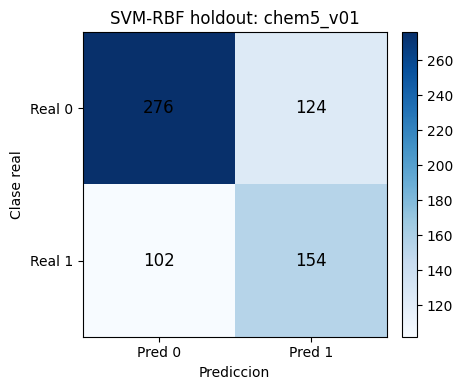

In [8]:
strict_bundle = final_bundles[STRICT_FEATURE_SET]
strict_holdout_predictions = pd.DataFrame({
    "source_index": X_test_raw.reset_index(drop=True)["source_index"],
    "y_true": y_test.reset_index(drop=True),
    "decision_score": strict_bundle["eval_scores"],
    "y_pred_default_threshold_0": strict_bundle["eval_pred"],
})
strict_holdout_predictions.to_csv(ARTIFACT_DIR / "strict_svm_holdout_predictions.csv", index=False)

cm_default = confusion_matrix(y_test, strict_bundle["eval_pred"], labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(4.8, 4.0))
im = ax.imshow(cm_default, cmap="Blues")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["Real 0", "Real 1"])
ax.set_title(f"SVM-RBF holdout: {STRICT_FEATURE_SET}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_default[i, j]), ha="center", va="center", color="black", fontsize=12)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "strict_svm_holdout_confusion_matrix.png", dpi=160)
plt.show()

## 5. Auditoria de threshold

La comparacion estricta usa `SVC.predict()`, equivalente a threshold 0 sobre `decision_function`. Tambien calculamos un threshold elegido por F1 OOF en training. Esto sirve para explicar por que un F1 >= 0.60 puede lograrse moviendo el threshold, pero no debe confundirse con una politica segura de potabilidad.

In [9]:
strict_fold_metrics, strict_oof_predictions = cross_validated_oof(
    X_train_raw,
    y_train,
    STRICT_FEATURES,
    STRICT_C,
    STRICT_GAMMA,
    balance_training=True,
)
strict_fold_metrics.to_csv(ARTIFACT_DIR / "strict_svm_cv_fold_metrics.csv", index=False)
strict_oof_predictions.to_csv(ARTIFACT_DIR / "strict_svm_oof_predictions.csv", index=False)

oof_default_metrics = classification_metrics(
    strict_oof_predictions["y_true"], strict_oof_predictions["y_pred"]
)
best_threshold, oof_threshold_metrics = choose_threshold_max_f1(
    strict_oof_predictions["y_true"], strict_oof_predictions["decision_score"]
)
holdout_threshold_pred = (strict_bundle["eval_scores"] >= best_threshold).astype(int)
holdout_threshold_metrics = classification_metrics(y_test, holdout_threshold_pred)

threshold_audit = pd.DataFrame([
    {"split": "train_oof", "policy": "default_threshold_0", "threshold": 0.0, **oof_default_metrics},
    {"split": "train_oof", "policy": "oof_max_f1_threshold", "threshold": best_threshold, **oof_threshold_metrics},
    {"split": "holdout", "policy": "default_threshold_0", "threshold": 0.0, **classification_metrics(y_test, strict_bundle["eval_pred"])},
    {"split": "holdout", "policy": "oof_max_f1_threshold", "threshold": best_threshold, **holdout_threshold_metrics},
])
threshold_audit.to_csv(ARTIFACT_DIR / "threshold_audit.csv", index=False)

display(threshold_audit[[
    "split", "policy", "threshold",
    "accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc",
    "tn", "fp", "fn", "tp",
]])

print(f"Threshold OOF que maximiza F1: {best_threshold:.6f}")
print("Regla de sklearn: se predice clase 1 si decision_score >= threshold.")

,split,policy,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp
0,train_oof,default_threshold_0,0.000000,0.635496,0.529515,0.588063,0.557255,0.665832,0.626947,0.249923,1064,534,421,601
1,train_oof,oof_max_f1_threshold,-0.736891,0.546183,0.456351,0.854207,0.594889,0.349186,0.601697,0.223504,558,1040,149,873
2,holdout,default_threshold_0,0.000000,0.655488,0.553957,0.601562,0.576779,0.690000,0.645781,0.287815,276,124,102,154
3,holdout,oof_max_f1_threshold,-0.736891,0.527439,0.443515,0.828125,0.577657,0.335000,0.581562,0.178956,134,266,44,212


Threshold OOF que maximiza F1: -0.736891
Regla de sklearn: se predice clase 1 si decision_score >= threshold.


## 6. Subconjunto balanceado de 80 muestras para QSVM

Estrategia seleccionada:

- usar solo el training split, nunca el holdout de 656 filas;
- usar las cinco variables de `chem5_v01`;
- entrenar una SVM auxiliar de ranking únicamente en training, sin submuestreo;
- ordenar cada clase por `decision_score`;
- elegir 40 muestras por clase distribuidas uniformemente por cuantiles del score;
- asignar 5 folds estratificados, cada uno con 8 no potables y 8 potables.

**Cómo se usan las 80 filas:** no existe un único test fijo de 16 filas. En cada fold se entrenan los modelos con 64 filas y se validan con las 16 restantes. Al rotar los cinco folds, cada una de las 80 filas aparece exactamente una vez como validación y cuatro veces dentro del training. Las predicciones OOF agregan esas cinco validaciones y permiten evaluar las 80 muestras sin predecir sobre las mismas filas con las que se entrenó cada fold.

Esto evita seleccionar solo muestras fáciles y conserva ejemplos desde extremos hasta frontera de decisión. El conjunto de 80 es una población experimental congelada para comparación SVM–QSVM; no es un test externo independiente ni una muestra aleatoria del dataset completo.


In [10]:
ranking_metrics, ranking_bundle = fit_final_svm(
    X_train_raw,
    y_train,
    X_train_raw,
    y_train,
    STRICT_FEATURES,
    STRICT_C,
    STRICT_GAMMA,
    balance_training=False,
)

X_train_reset = X_train_raw.reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
X_test_source_indices = set(X_test_raw["source_index"].astype(int))

positions_80 = select_score_quantile_subset(
    y_train_reset,
    ranking_bundle["train_scores"],
    n_per_class=QUANTUM_ROWS // 2,
)

quantum80_raw = X_train_reset.iloc[positions_80].copy().reset_index(drop=True)
quantum80_raw[TARGET] = y_train_reset.iloc[positions_80].to_numpy(dtype=int)
expected_selected_columns = ["source_index", *LOCKED_FEATURES, TARGET]
quantum80_selected = quantum80_raw[expected_selected_columns].copy()

if list(quantum80_selected.columns) != expected_selected_columns:
    raise RuntimeError(
        f"Esquema inesperado en quantum80_selected_features.csv: {list(quantum80_selected.columns)}"
    )
if "Solids" in quantum80_selected.columns:
    raise RuntimeError("Artifact inválido: quantum80_selected_features.csv no debe contener Solids.")
if "Conductivity" not in quantum80_selected.columns:
    raise RuntimeError("Artifact inválido: quantum80_selected_features.csv debe contener Conductivity.")

if set(quantum80_raw["source_index"].astype(int)).intersection(X_test_source_indices):
    raise RuntimeError("El subconjunto de 80 intersecta el holdout; revisar seleccion.")

folds_80 = assign_balanced_folds(quantum80_raw[TARGET], n_splits=N_SPLITS, seed=SEEDS["outer_folds"])
quantum80_folds = pd.DataFrame({
    "position": np.arange(len(quantum80_raw)),
    "source_index": quantum80_raw["source_index"].astype(int),
    "Potability": quantum80_raw[TARGET].astype(int),
    "validation_fold": folds_80,
})

# Eliminar outputs potencialmente obsoletos antes de escribir la generación bloqueada.
for stale_name in [
    "quantum80_selected_features.csv",
    "quantum80_manifest.json",
    "quantum80_svm_cv_summary.csv",
    "quantum80_svm_grid_fold_metrics.csv",
    "quantum80_svm_best_fold_metrics.csv",
    "quantum80_svm_oof_predictions.csv",
    "quantum80_svm_oof_metrics.csv",
]:
    stale_path = ARTIFACT_DIR / stale_name
    if stale_path.exists():
        stale_path.unlink()

quantum80_raw.to_csv(ARTIFACT_DIR / "quantum80_raw.csv", index=False)
quantum80_selected.to_csv(ARTIFACT_DIR / "quantum80_selected_features.csv", index=False)
quantum80_folds.to_csv(ARTIFACT_DIR / "quantum80_folds.csv", index=False)

fold_balance = (
    quantum80_folds
    .groupby(["validation_fold", "Potability"])
    .size()
    .rename("rows")
    .reset_index()
    .pivot(index="validation_fold", columns="Potability", values="rows")
    .rename(columns=CLASS_NAMES)
)

subset_report = {
    "rows": int(len(quantum80_raw)),
    "class_counts": quantum80_raw[TARGET].value_counts().sort_index().to_dict(),
    "feature_set": STRICT_FEATURE_SET,
    "features": STRICT_FEATURES,
    "feature_selection_policy": "predefined_physicochemical_basis",
    "feature_selection_reason": PREFERRED_FEATURE_REASON,
    "selection_strategy": "40 per class by evenly spaced quantiles of an unbalanced SVM ranking decision_score on training only",
    "ranking_model": {
        "C": STRICT_C,
        "gamma": STRICT_GAMMA,
        "balance_training": False,
    },
    "holdout_intersection": 0,
}
with (ARTIFACT_DIR / "quantum80_manifest.json").open("w", encoding="utf-8") as f:
    json.dump(subset_report, f, indent=2)

print(json.dumps(subset_report, indent=2))
display(fold_balance)
display(quantum80_selected.head(10))

{
  "rows": 80,
  "class_counts": {
    "0": 40,
    "1": 40
  },
  "feature_set": "chem5_v01",
  "features": [
    "Sulfate",
    "ph",
    "Conductivity",
    "Chloramines",
    "Hardness"
  ],
  "feature_selection_policy": "predefined_physicochemical_basis",
  "feature_selection_reason": "Se prioriza una base fisicoquimica interpretable: Sulfate, ph, Conductivity, Chloramines y Hardness. Conductivity reemplaza a Solids como proxy directo de la carga ionica disuelta; la pequena diferencia de CV se acepta como trade-off de dominio.",
  "selection_strategy": "40 per class by evenly spaced quantiles of an unbalanced SVM ranking decision_score on training only",
  "ranking_model": {
    "C": 10.0,
    "gamma": "auto",
    "balance_training": false
  },
  "holdout_intersection": 0
}


Potability,No potable,Potable
validation_fold,,
0,8,8
1,8,8
2,8,8
3,8,8
4,8,8


,source_index,Sulfate,ph,Conductivity,Chloramines,Hardness,Potability
0,284,259.979966,7.958984,327.623881,9.537735,171.483625,1
1,3028,376.055637,5.369584,401.833036,8.065886,170.835192,0
2,2720,342.029115,5.945989,471.122125,7.894120,151.685797,1
3,875,374.226926,4.489784,518.585253,8.486030,188.251939,0
4,1341,239.911902,NaN,362.500414,6.951666,194.445316,0
5,1102,335.668046,7.457980,482.637180,7.475273,183.461310,1
6,2696,NaN,7.889080,453.166987,7.296282,208.402367,0
7,1770,353.176328,6.732714,321.364518,7.396764,197.766974,0
8,3165,316.391974,9.370697,424.915677,7.762862,157.719364,1
9,2407,329.619336,5.916930,428.832746,6.774610,185.925021,1


## 7. SVM-RBF de referencia sobre las mismas 80 muestras

Esta métrica no reemplaza el holdout completo. Es la referencia local que debe compararse contra la QSVM porque usa las mismas 80 filas, las mismas cinco variables y los mismos cinco folds.

En cada fold: 64 filas entrenan y 16 validan. Las métricas finales son OOF sobre las 80 filas, no el resultado de un único split 64/16.


,feature_set,n_features,C,gamma,accuracy_mean,precision_mean,recall_mean,f1_mean,specificity_mean,balanced_accuracy_mean,mcc_mean
0,chem5_v01,5,10.0,0.01,0.5375,0.535714,0.650,0.577273,0.425,0.5375,0.074802
1,chem5_v01,5,0.1,0.01,0.5375,0.527692,0.600,0.534002,0.475,0.5375,0.108337
2,chem5_v01,5,1.0,0.01,0.5375,0.527692,0.600,0.534002,0.475,0.5375,0.108337
3,chem5_v01,5,0.1,scale,0.5000,0.526465,0.525,0.502173,0.475,0.5000,0.003813
4,chem5_v01,5,0.1,auto,0.5000,0.526465,0.525,0.502173,0.475,0.5000,0.003813
5,chem5_v01,5,10.0,scale,0.5250,0.541623,0.475,0.494879,0.575,0.5250,0.051770
6,chem5_v01,5,10.0,auto,0.5250,0.541623,0.475,0.494879,0.575,0.5250,0.051770
7,chem5_v01,5,1.0,scale,0.4875,0.406305,0.500,0.443202,0.475,0.4875,-0.063779
8,chem5_v01,5,1.0,auto,0.4875,0.406305,0.500,0.443202,0.475,0.4875,-0.063779


,C,gamma,accuracy,precision,recall,f1,specificity,balanced_accuracy,mcc,tn,fp,fn,tp
0,10.0,0.01,0.5375,0.530612,0.65,0.58427,0.425,0.5375,0.076974,17,23,14,26


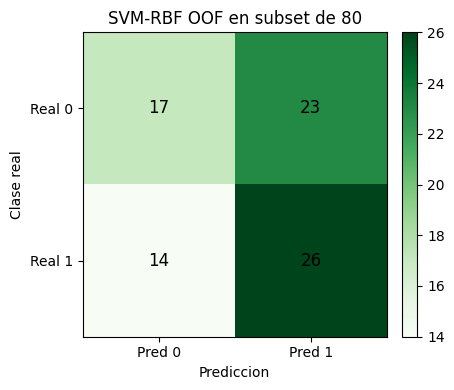

In [11]:
subset_cv_summary, subset_cv_fold_metrics = cross_validate_grid(
    quantum80_raw,
    quantum80_raw[TARGET].astype(int),
    STRICT_FEATURES,
    balance_training=False,
    fold_assignments=quantum80_folds["validation_fold"],
)
subset_cv_summary = subset_cv_summary.sort_values(
    ["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False
).reset_index(drop=True)
subset_cv_summary.insert(0, "feature_set", STRICT_FEATURE_SET)
subset_cv_summary.insert(1, "n_features", len(STRICT_FEATURES))
subset_cv_summary.insert(2, "features", "|".join(STRICT_FEATURES))

subset_best = subset_cv_summary.iloc[0]
subset_best_fold_metrics, subset_oof_predictions = cross_validated_oof(
    quantum80_raw,
    quantum80_raw[TARGET].astype(int),
    STRICT_FEATURES,
    float(subset_best["C"]),
    subset_best["gamma"],
    balance_training=False,
    fold_assignments=quantum80_folds["validation_fold"],
)
subset_oof_metrics = classification_metrics(
    subset_oof_predictions["y_true"], subset_oof_predictions["y_pred"]
)

subset_cv_summary.to_csv(ARTIFACT_DIR / "quantum80_svm_cv_summary.csv", index=False)
subset_cv_fold_metrics.to_csv(ARTIFACT_DIR / "quantum80_svm_grid_fold_metrics.csv", index=False)
subset_best_fold_metrics.to_csv(ARTIFACT_DIR / "quantum80_svm_best_fold_metrics.csv", index=False)
subset_oof_predictions.to_csv(ARTIFACT_DIR / "quantum80_svm_oof_predictions.csv", index=False)
pd.DataFrame([{**{"feature_set": STRICT_FEATURE_SET, "C": subset_best["C"], "gamma": subset_best["gamma"]}, **subset_oof_metrics}]).to_csv(
    ARTIFACT_DIR / "quantum80_svm_oof_metrics.csv", index=False
)

display(subset_cv_summary[[
    "feature_set", "n_features", "C", "gamma",
    "accuracy_mean", "precision_mean", "recall_mean", "f1_mean",
    "specificity_mean", "balanced_accuracy_mean", "mcc_mean",
]].head(9))

display(pd.DataFrame([{**{"C": subset_best["C"], "gamma": subset_best["gamma"]}, **subset_oof_metrics}])[[
    "C", "gamma", "accuracy", "precision", "recall", "f1", "specificity", "balanced_accuracy", "mcc", "tn", "fp", "fn", "tp"
]])

cm_subset = confusion_matrix(subset_oof_predictions["y_true"], subset_oof_predictions["y_pred"], labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(4.8, 4.0))
im = ax.imshow(cm_subset, cmap="Greens")
ax.set_xticks([0, 1], ["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], ["Real 0", "Real 1"])
ax.set_title("SVM-RBF OOF en subset de 80")
for i in range(2):
    for j in range(2):
        ax.text(j, i, int(cm_subset[i, j]), ha="center", va="center", color="black", fontsize=12)
ax.set_xlabel("Prediccion")
ax.set_ylabel("Clase real")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(ARTIFACT_DIR / "quantum80_svm_oof_confusion_matrix.png", dpi=160)
plt.show()

## 8. Resumen ejecutivo de Parte 1 y Parte 2

In [12]:
strict_holdout_row = holdout_metrics.loc[holdout_metrics["feature_set"] == STRICT_FEATURE_SET].iloc[0]
threshold_holdout_row = threshold_audit.query("split == 'holdout' and policy == 'oof_max_f1_threshold'").iloc[0]
subset_row = pd.read_csv(ARTIFACT_DIR / "quantum80_svm_oof_metrics.csv").iloc[0]

summary_md = f'''
### Decisiones para continuar

- **Feature set predefinido:** `{STRICT_FEATURE_SET}` con {len(STRICT_FEATURES)} variables: `{', '.join(STRICT_FEATURES)}`. Se prioriza su coherencia fisicoquimica aunque `chem5_prev` tenga una ventaja pequena de CV; reduce el costo cuantico potencial de 9 a {len(STRICT_FEATURES)} qubits/features.
- **SVM-RBF estricta en holdout:** `C={STRICT_C:g}`, `gamma={STRICT_GAMMA}`, F1={strict_holdout_row['f1']:.3f}, precision={strict_holdout_row['precision']:.3f}, recall={strict_holdout_row['recall']:.3f}, specificity={strict_holdout_row['specificity']:.3f}.
- **Threshold auditado:** un threshold OOF negativo (`{best_threshold:.3f}`) sube el F1 de holdout a {threshold_holdout_row['f1']:.3f}, pero aumenta falsos positivos a {int(threshold_holdout_row['fp'])}. Esto sirve como benchmark academico, no como regla segura para certificar agua potable.
- **Subconjunto QSVM listo:** 80 filas balanceadas, 40/40 por clase. Cada fold usa 64 para training y 16 para validacion; las predicciones OOF cubren las 80. La SVM-RBF local obtiene F1 OOF={subset_row['f1']:.3f} con `C={subset_row['C']}` y `gamma={subset_row['gamma']}`.

### Archivos generados

Todos los artefactos nuevos quedaron en:

`{ARTIFACT_DIR}`
'''

display(Markdown(summary_md))


### Decisiones para continuar

- **Feature set predefinido:** `chem5_v01` con 5 variables: `Sulfate, ph, Conductivity, Chloramines, Hardness`. Se prioriza su coherencia fisicoquimica aunque `chem5_prev` tenga una ventaja pequena de CV; reduce el costo cuantico potencial de 9 a 5 qubits/features.
- **SVM-RBF estricta en holdout:** `C=10`, `gamma=auto`, F1=0.577, precision=0.554, recall=0.602, specificity=0.690.
- **Threshold auditado:** un threshold OOF negativo (`-0.737`) sube el F1 de holdout a 0.578, pero aumenta falsos positivos a 266. Esto sirve como benchmark academico, no como regla segura para certificar agua potable.
- **Subconjunto QSVM listo:** 80 filas balanceadas, 40/40 por clase. Cada fold usa 64 para training y 16 para validacion; las predicciones OOF cubren las 80. La SVM-RBF local obtiene F1 OOF=0.584 con `C=10.0` y `gamma=0.01`.

### Archivos generados

Todos los artefactos nuevos quedaron en:

`/content/drive/MyDrive/Colab Notebooks/artifacts_v1`
